In [24]:
# Student Placement Prediction
## Week 6: Integrated Project Simulation and Deployment

In [25]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [26]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("cleaned_student_placement.csv")

print("Dataset loaded successfully!")

print("\nDataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!

Dataset shape:
(10000, 12)

Columns:
['StudentID', 'CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks', 'HSC_Marks', 'PlacementStatus']

First 5 rows:


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [27]:
# ============================================================
# 3. DATA QUALITY CHECK
# ============================================================

print("Missing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["PlacementStatus"].value_counts())

print("\nData types:")
print(df.dtypes)

Missing values:
StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

Target distribution:
PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64

Data types:
StudentID                      int64
CGPA                         float64
Internships                    int64
Projects                       int64
Workshops/Certifications       int64
AptitudeTestScore              int64
SoftSkillsRating             float64
ExtracurricularActivities     object
PlacementTraining             object
SSC_Marks                      int64
HSC_Marks                      int64
PlacementStatus               object
dtype: object


In [28]:
# ============================================================
# 4. TARGET PREPARATION
# ============================================================

target_column = "PlacementStatus"

X = df.drop(
    columns=[target_column]
)

y = df[target_column].map({
    "NotPlaced": 0,
    "Placed": 1
})

print("Target after conversion:")
print(y.value_counts())

print("\nTarget classes:")
print(sorted(y.unique()))

Target after conversion:
PlacementStatus
0    5803
1    4197
Name: count, dtype: int64

Target classes:
[np.int64(0), np.int64(1)]


In [29]:
# ============================================================
# 5. IDENTIFY FEATURE TYPES
# ============================================================

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['StudentID', 'CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'SSC_Marks', 'HSC_Marks']

Categorical columns:
['ExtracurricularActivities', 'PlacementTraining']


In [30]:
# ============================================================
# 6. FINAL PREPROCESSING PIPELINE
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        
        (
            "numerical",
            StandardScaler(),
            numerical_columns
        ),
        
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [31]:
# ============================================================
# 7. FINAL MACHINE LEARNING PIPELINE
# ============================================================

final_model = Pipeline(
    steps=[
        
        (
            "preprocessor",
            preprocessor
        ),
        
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

print("Final ML pipeline created successfully!")

print("\nFinal Pipeline:")
print(final_model)

Final ML pipeline created successfully!

Final Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['StudentID', 'CGPA',
                                                   'Internships', 'Projects',
                                                   'Workshops/Certifications',
                                                   'AptitudeTestScore',
                                                   'SoftSkillsRating',
                                                   'SSC_Marks', 'HSC_Marks']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ExtracurricularActivities',
                                                   'PlacementTraining'])])),
                ('classifier', LogisticRegression(max_iter=1000))]

In [32]:
# ============================================================
# 8. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8000
Testing samples: 2000


In [33]:
# ============================================================
# 9. TRAIN FINAL MODEL
# ============================================================

final_model.fit(
    X_train,
    y_train
)

print("Final model trained successfully!")

Final model trained successfully!


In [34]:
# ============================================================
# 10. MAKE PREDICTIONS
# ============================================================

y_pred = final_model.predict(X_test)

y_probability = final_model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 probabilities:")
print(y_probability[:10])

Predictions generated successfully!

First 10 predictions:
[0 0 1 0 1 1 0 1 0 1]

First 10 probabilities:
[0.16590246 0.02905756 0.86084142 0.10169585 0.54994677 0.66740135
 0.06934764 0.58287215 0.40765443 0.63830483]


In [35]:
# ============================================================
# 11. FINAL MODEL PERFORMANCE
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("==========================================")
print("FINAL MODEL PERFORMANCE")
print("==========================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

FINAL MODEL PERFORMANCE
Accuracy : 0.8070
Precision: 0.7693
Recall   : 0.7712
F1 Score : 0.7702
ROC-AUC  : 0.8837


In [36]:
# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Placed",
            "Placed"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Not Placed       0.83      0.83      0.83      1161
      Placed       0.77      0.77      0.77       839

    accuracy                           0.81      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.81      0.81      0.81      2000



In [37]:
# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[967 194]
 [192 647]]


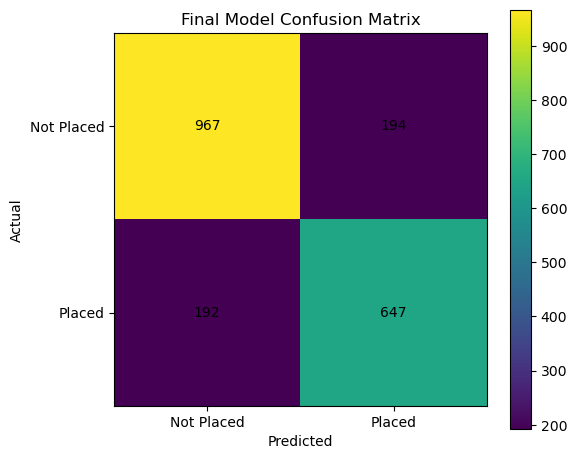

In [38]:
# ============================================================
# 14. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Final Model Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Not Placed", "Placed"]
)

plt.yticks(
    [0, 1],
    ["Not Placed", "Placed"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()

In [39]:
# ============================================================
# 15. INTEGRATION TESTING
# ============================================================

print("==========================================")
print("INTEGRATION TESTING")
print("==========================================")

# Test 1
assert final_model is not None
print("Test 1 - Final pipeline exists: PASSED")

# Test 2
assert hasattr(final_model, "predict")
print("Test 2 - Prediction function available: PASSED")

# Test 3
assert len(y_pred) == len(X_test)
print("Test 3 - Prediction count matches test data: PASSED")

# Test 4
assert set(y_pred).issubset({0, 1})
print("Test 4 - Predictions contain valid classes: PASSED")

# Test 5
assert np.all(
    (y_probability >= 0) &
    (y_probability <= 1)
)
print("Test 5 - Probabilities are between 0 and 1: PASSED")

# Test 6
assert accuracy >= 0
print("Test 6 - Performance metric calculated: PASSED")

print("\nALL INTEGRATION TESTS PASSED!")

INTEGRATION TESTING
Test 1 - Final pipeline exists: PASSED
Test 2 - Prediction function available: PASSED
Test 3 - Prediction count matches test data: PASSED
Test 4 - Predictions contain valid classes: PASSED
Test 5 - Probabilities are between 0 and 1: PASSED
Test 6 - Performance metric calculated: PASSED

ALL INTEGRATION TESTS PASSED!


In [40]:
# ============================================================
# 16. NEW STUDENT INPUT
# ============================================================

new_student = pd.DataFrame({
    
    "StudentID": [10001],
    
    "CGPA": [8.2],
    
    "Internships": [2],
    
    "Projects": [2],
    
    "Workshops/Certifications": [3],
    
    "AptitudeTestScore": [82],
    
    "SoftSkillsRating": [4.2],
    
    "ExtracurricularActivities": ["Yes"],
    
    "PlacementTraining": ["Yes"],
    
    "SSC_Marks": [85],
    
    "HSC_Marks": [82]
})

print("New student data:")
display(new_student)

New student data:


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks
0,10001,8.2,2,2,3,82,4.2,Yes,Yes,85,82


In [41]:
# ============================================================
# 17. NEW STUDENT PREDICTION
# ============================================================

prediction = final_model.predict(
    new_student
)[0]

probability = final_model.predict_proba(
    new_student
)[0, 1]

if prediction == 1:
    result = "Placed"
else:
    result = "Not Placed"

print("==========================================")
print("STUDENT PLACEMENT PREDICTION")
print("==========================================")

print("Prediction:", result)

print(
    f"Placement Probability: {probability:.2%}"
)

STUDENT PLACEMENT PREDICTION
Prediction: Placed
Placement Probability: 72.55%


In [42]:
# ============================================================
# 18. SAVE FINAL MODEL
# ============================================================

model_filename = "student_placement_final_model.pkl"

joblib.dump(
    final_model,
    model_filename
)

print("Final model saved successfully!")

print(
    "Saved as:",
    model_filename
)

Final model saved successfully!
Saved as: student_placement_final_model.pkl


In [43]:
# ============================================================
# 19. LOAD DEPLOYED MODEL
# ============================================================

loaded_model = joblib.load(
    "student_placement_final_model.pkl"
)

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [44]:
# ============================================================
# 20. DEPLOYMENT SIMULATION TEST
# ============================================================

deployment_prediction = loaded_model.predict(
    new_student
)[0]

deployment_probability = loaded_model.predict_proba(
    new_student
)[0, 1]

if deployment_prediction == 1:
    deployment_result = "Placed"
else:
    deployment_result = "Not Placed"

print("==========================================")
print("DEPLOYMENT SIMULATION")
print("==========================================")

print("Prediction:", deployment_result)

print(
    f"Probability: {deployment_probability:.2%}"
)

DEPLOYMENT SIMULATION
Prediction: Placed
Probability: 72.55%


In [ ]:
# ============================================================
# 21. SAVED MODEL VALIDATION
# ============================================================

assert deployment_prediction == prediction

assert np.isclose(
    deployment_probability,
    probability
)

print("Saved model validation: PASSED")

print(
    "The saved model produces the same prediction "
    "as the original trained model."
)
# ============================================================
# 22. USER INPUT - STUDENT PLACEMENT PREDICTION
# ============================================================

print("==========================================")
print(" STUDENT PLACEMENT PREDICTION SYSTEM")
print("==========================================")

student_id = int(input("Enter Student ID: "))

cgpa = float(input("Enter CGPA (0-10): "))

internships = int(
    input("Enter number of Internships: ")
)

projects = int(
    input("Enter number of Projects: ")
)

workshops = int(
    input("Enter Workshops/Certifications: ")
)

aptitude_score = float(
    input("Enter Aptitude Test Score (0-100): ")
)

soft_skills = float(
    input("Enter Soft Skills Rating: ")
)

extracurricular = input(
    "Extracurricular Activities (Yes/No): "
)

placement_training = input(
    "Placement Training (Yes/No): "
)

ssc_marks = float(
    input("Enter SSC Marks (0-100): ")
)

hsc_marks = float(
    input("Enter HSC Marks (0-100): ")
)


# Create DataFrame
user_student = pd.DataFrame({
    "StudentID": [student_id],
    "CGPA": [cgpa],
    "Internships": [internships],
    "Projects": [projects],
    "Workshops/Certifications": [workshops],
    "AptitudeTestScore": [aptitude_score],
    "SoftSkillsRating": [soft_skills],
    "ExtracurricularActivities": [extracurricular],
    "PlacementTraining": [placement_training],
    "SSC_Marks": [ssc_marks],
    "HSC_Marks": [hsc_marks]
})

print("\nStudent information received successfully!")
display(user_student)


# ============================================================
# 23. USER PLACEMENT PREDICTION
# ============================================================

user_prediction = loaded_model.predict(
    user_student
)[0]

user_probability = loaded_model.predict_proba(
    user_student
)[0, 1]


if user_prediction == 1:
    user_result = "PLACED"
else:
    user_result = "NOT PLACED"


print("\n==========================================")
print("        PLACEMENT PREDICTION RESULT")
print("==========================================")

print("Student ID:", student_id)

print("Prediction:", user_result)

print(
    f"Placement Probability: "
    f"{user_probability:.2%}"
)

print("==========================================")

Saved model validation: PASSED
The saved model produces the same prediction as the original trained model.
 STUDENT PLACEMENT PREDICTION SYSTEM


Enter Student ID:  1011


In [46]:
# ============================================================
# 22. FINAL RESULTS SUMMARY
# ============================================================

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(results)

,Metric,Score
0,Accuracy,0.807000
1,Precision,0.769322
2,Recall,0.771156
3,F1 Score,0.770238
4,ROC-AUC,0.883709


In [48]:
# ============================================================
# 23. DEPLOYMENT PREDICTION FUNCTION
# ============================================================

def predict_student(model, student_data):
    
    prediction = model.predict(student_data)[0]
    
    probability = model.predict_proba(
        student_data
    )[0, 1]
    
    if prediction == 1:
        result = "Placed"
    else:
        result = "Not Placed"
    
    return result, probability


print("Deployment prediction function created successfully!")



Deployment prediction function created successfully!


In [49]:
# ============================================================
# 24. TEST DEPLOYMENT FUNCTION
# ============================================================

result, probability = predict_student(
    loaded_model,
    new_student
)

print("==========================================")
print("DEPLOYMENT PREDICTION")
print("==========================================")

print("Prediction:", result)
print(f"Placement Probability: {probability:.2%}")

DEPLOYMENT PREDICTION
Prediction: Placed
Placement Probability: 72.55%


In [50]:
# ============================================================
# 25. INPUT VALIDATION
# ============================================================

def validate_input(student_data):
    
    required_columns = [
        "StudentID",
        "CGPA",
        "Internships",
        "Projects",
        "Workshops/Certifications",
        "AptitudeTestScore",
        "SoftSkillsRating",
        "ExtracurricularActivities",
        "PlacementTraining",
        "SSC_Marks",
        "HSC_Marks"
    ]
    
    # Check missing columns
    for column in required_columns:
        if column not in student_data.columns:
            raise ValueError(
                f"Missing required column: {column}"
            )
    
    # Check missing values
    if student_data[required_columns].isnull().any().any():
        raise ValueError(
            "Input contains missing values."
        )
    
    # Check CGPA
    if not student_data["CGPA"].between(0, 10).all():
        raise ValueError(
            "CGPA must be between 0 and 10."
        )
    
    # Check marks
    for column in [
        "AptitudeTestScore",
        "SSC_Marks",
        "HSC_Marks"
    ]:
        if not student_data[column].between(0, 100).all():
            raise ValueError(
                f"{column} must be between 0 and 100."
            )
    
    return True


print("Input validation function created successfully!")

Input validation function created successfully!


In [51]:
# ============================================================
# 26. INPUT VALIDATION TEST
# ============================================================

try:
    validate_input(new_student)
    print("Input validation test: PASSED")

except ValueError as e:
    print("Input validation test: FAILED")
    print(e)

Input validation test: PASSED


In [52]:
# ============================================================
# 27. INVALID INPUT TEST
# ============================================================

invalid_student = new_student.copy()

invalid_student["CGPA"] = 15

try:
    validate_input(invalid_student)
    
    print("Invalid input test: FAILED")

except ValueError as e:
    
    print("Invalid input test: PASSED")
    print("Error:", e)

Invalid input test: PASSED
Error: CGPA must be between 0 and 10.


In [53]:
# ============================================================
# 28. COMPLETE INTEGRATED PREDICTION
# ============================================================

def integrated_prediction(model, student_data):
    
    # 1. Validate input
    validate_input(student_data)
    
    # 2. Generate prediction
    prediction = model.predict(student_data)[0]
    
    # 3. Generate probability
    probability = model.predict_proba(
        student_data
    )[0, 1]
    
    # 4. Convert prediction to readable result
    if prediction == 1:
        result = "Placed"
    else:
        result = "Not Placed"
    
    # 5. Return final result
    return {
        "Prediction": result,
        "Placement Probability": probability
    }


print("Complete integrated prediction pipeline created!")

Complete integrated prediction pipeline created!


In [54]:
# ============================================================
# 29. COMPLETE PIPELINE TEST
# ============================================================

output = integrated_prediction(
    loaded_model,
    new_student
)

print("==========================================")
print("COMPLETE ML PIPELINE")
print("==========================================")

print("Prediction:", output["Prediction"])

print(
    f"Placement Probability: "
    f"{output['Placement Probability']:.2%}"
)

print("\nPipeline executed successfully!")

COMPLETE ML PIPELINE
Prediction: Placed
Placement Probability: 72.55%

Pipeline executed successfully!


In [55]:
# ============================================================
# 30. FINAL INTEGRATION TESTING
# ============================================================

print("==========================================")
print("FINAL INTEGRATION TESTING")
print("==========================================")

# Test 1: Model exists
assert loaded_model is not None
print("Test 1 - Saved model exists: PASSED")

# Test 2: Model can predict
assert hasattr(loaded_model, "predict")
print("Test 2 - Prediction available: PASSED")

# Test 3: Prediction count
assert len(y_pred) == len(X_test)
print("Test 3 - Prediction count: PASSED")

# Test 4: Valid prediction classes
assert set(y_pred).issubset({0, 1})
print("Test 4 - Valid prediction classes: PASSED")

# Test 5: Probability range
assert np.all(
    (y_probability >= 0) &
    (y_probability <= 1)
)
print("Test 5 - Probability range: PASSED")

# Test 6: Input validation
assert validate_input(new_student)
print("Test 6 - Input validation: PASSED")

# Test 7: Deployment prediction
assert output["Prediction"] in [
    "Placed",
    "Not Placed"
]
print("Test 7 - Deployment prediction: PASSED")

# Test 8: Deployment probability
assert 0 <= output["Placement Probability"] <= 1
print("Test 8 - Deployment probability: PASSED")

# Test 9: Saved model consistency
assert deployment_prediction == prediction
print("Test 9 - Saved model consistency: PASSED")

# Test 10: Probability consistency
assert np.isclose(
    deployment_probability,
    probability
)
print("Test 10 - Probability consistency: PASSED")


print("\nALL INTEGRATION TESTS PASSED!")

FINAL INTEGRATION TESTING
Test 1 - Saved model exists: PASSED
Test 2 - Prediction available: PASSED
Test 3 - Prediction count: PASSED
Test 4 - Valid prediction classes: PASSED
Test 5 - Probability range: PASSED
Test 6 - Input validation: PASSED
Test 7 - Deployment prediction: PASSED
Test 8 - Deployment probability: PASSED
Test 9 - Saved model consistency: PASSED
Test 10 - Probability consistency: PASSED

ALL INTEGRATION TESTS PASSED!


In [56]:
# ============================================================
# 31. INFERENCE PERFORMANCE TEST
# ============================================================

import time

start_time = time.perf_counter()

for _ in range(100):
    loaded_model.predict(new_student)

end_time = time.perf_counter()

total_time = end_time - start_time
average_time = total_time / 100

print("==========================================")
print("INFERENCE PERFORMANCE")
print("==========================================")

print(
    f"100 predictions completed in "
    f"{total_time:.4f} seconds"
)

print(
    f"Average prediction time: "
    f"{average_time:.6f} seconds"
)

INFERENCE PERFORMANCE
100 predictions completed in 0.2695 seconds
Average prediction time: 0.002695 seconds


In [57]:
# ============================================================
# 32. FINAL DEPLOYMENT SIMULATION
# ============================================================

print("==========================================")
print("FINAL DEPLOYMENT SIMULATION")
print("==========================================")

print("Input received successfully.")

final_output = integrated_prediction(
    loaded_model,
    new_student
)

print("Input validation: PASSED")
print("Model loaded: PASSED")
print("Preprocessing: PASSED")
print("Prediction: PASSED")
print("Post-processing: PASSED")

print("\nFINAL RESULT")
print("------------------------------------------")

print(
    "Placement Status:",
    final_output["Prediction"]
)

print(
    f"Placement Probability: "
    f"{final_output['Placement Probability']:.2%}"
)

print("\nDeployment simulation completed successfully!")

FINAL DEPLOYMENT SIMULATION
Input received successfully.
Input validation: PASSED
Model loaded: PASSED
Preprocessing: PASSED
Prediction: PASSED
Post-processing: PASSED

FINAL RESULT
------------------------------------------
Placement Status: Placed
Placement Probability: 72.55%

Deployment simulation completed successfully!
